In [1]:
# Task 2: Credit Risk Prediction

In [2]:
## Objective
#Predict whether a loan applicant is likely to repay a loan using machine learning.

In [3]:
## Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
## Load Dataset
df = pd.read_csv(r"C:\Task 2\loan_dataset_20000.csv")
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [5]:
## Dataset Shape
df.shape

(20000, 22)

In [6]:
## Column Names
df.columns

Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')

In [7]:
## Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [8]:
## Statistical Summary
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637766,3629.136466,0.177019,679.25695,15129.300909,12.400626,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [9]:
## Missing Values Check
df.isnull().sum()

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64

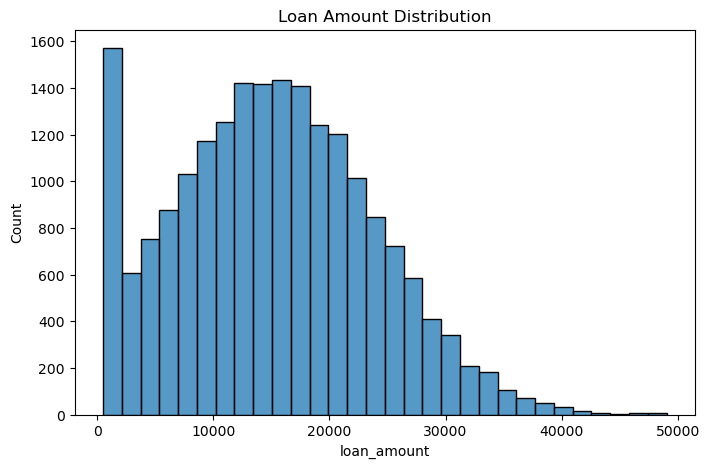

In [10]:
## Loan Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amount'], bins=30)
plt.title("Loan Amount Distribution")
plt.show()

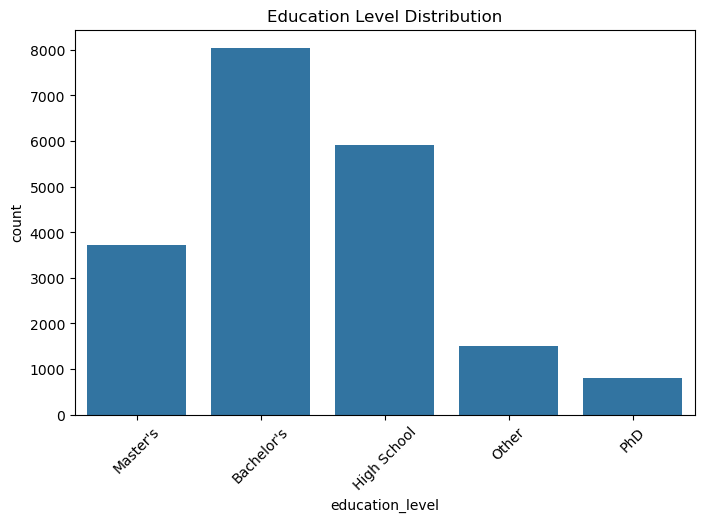

In [11]:
## Education Level Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='education_level', data=df)
plt.title("Education Level Distribution")
plt.xticks(rotation=45)
plt.show()

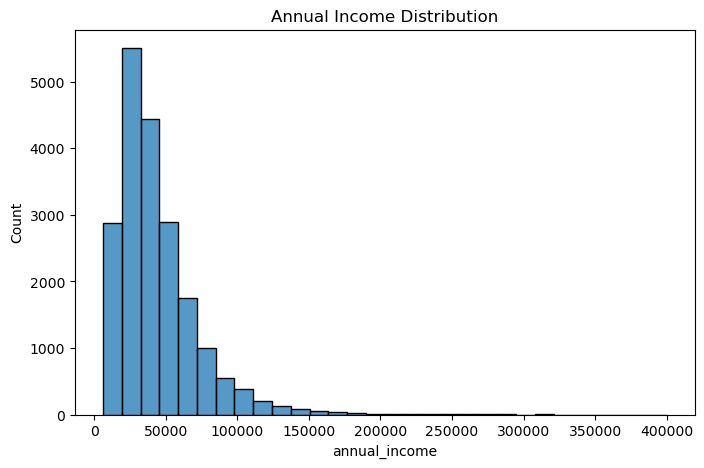

In [12]:
## Annual Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['annual_income'], bins=30)
plt.title("Annual Income Distribution")
plt.show()

In [14]:
## Data Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [15]:
## Features and Target
X = df.drop("loan_paid_back", axis=1)
y = df["loan_paid_back"]

In [16]:
## Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [17]:
## Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
## Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [19]:
## Prediction
y_pred = model.predict(X_test)

In [20]:
## Accuracy Score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8835


In [21]:
## Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 457  361]
 [ 105 3077]]


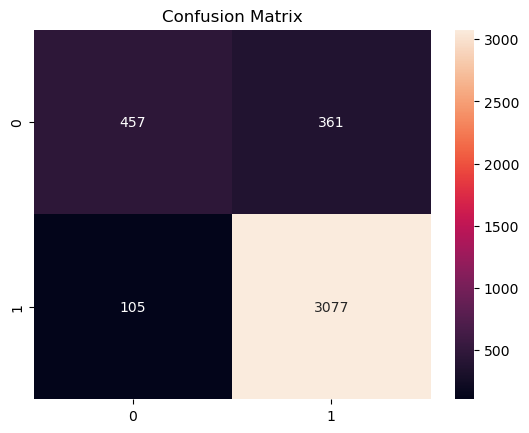

In [22]:
## Confusion Matrix Visualization
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [23]:
## Conclusion
print("The dataset was successfully analyzed and preprocessed.")
print("Logistic Regression was used for loan repayment prediction.")
print("The model was evaluated using Accuracy Score and Confusion Matrix.")

The dataset was successfully analyzed and preprocessed.
Logistic Regression was used for loan repayment prediction.
The model was evaluated using Accuracy Score and Confusion Matrix.
